In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['ABSL_MIN_LOG_LEVEL'] = '3'
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import layers
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU') 
tf.config.experimental.set_memory_growth(gpus[0], True)

### Zadanie 9

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

dim = X_train.max()
X_train = X_train.astype('float32') / dim
X_test = X_test.astype('float32') / dim
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]
classes = len(np.unique(y_train))

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

model = keras.Sequential(
    [
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, kernel_size=(3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, kernel_size=(3,3), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, kernel_size=(3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, kernel_size=(3,3), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, kernel_size=(3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='softmax'),
        layers.Dropout(0.25),
        layers.Dense(classes, activation='softmax')
    ]
)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, 
                    y_train, 
                    batch_size=128, 
                    epochs=30, 
                    validation_data=(X_val, y_val),
                    callbacks=[
                        EarlyStopping(patience=4, restore_best_weights=True),
                        ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-6)
                    ],
                    verbose=1)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
y_pred = model.predict(X_test)

E0000 00:00:1774737167.841856   18093 gpu_process_state.cc:83] TF_GPU_ALLOCATOR=cuda_malloc_async environment found, but TensorFlow was not compiled with CUDA support.
I0000 00:00:1774737167.841890   18093 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4360 MB memory:  -> device: 0, name: AMD Radeon RX 6600, pci bus id: 0000:0a:00.0


Epoch 1/30
  5/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1039 - loss: 2.3007 

I0000 00:00:1774737175.921292   18158 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.3634 - loss: 1.9287 - val_accuracy: 0.1013 - val_loss: 2.3928 - learning_rate: 0.0010
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.3912 - loss: 1.5978 - val_accuracy: 0.4832 - val_loss: 1.4227 - learning_rate: 0.0010
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.3986 - loss: 1.4584 - val_accuracy: 0.4900 - val_loss: 1.2686 - learning_rate: 0.0010
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.4004 - loss: 1.3865 - val_accuracy: 0.4952 - val_loss: 1.1792 - learning_rate: 0.0010
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.4056 - loss: 1.3444 - val_accuracy: 0.4975 - val_loss: 1.1346 - learning_rate: 0.0010
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.4799 - loss: 1.2846 - val_accuracy: 0.6685 - val_loss: 1.0042 - learning_rate: 0.0010
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.5214 - loss: 1.1797 - val

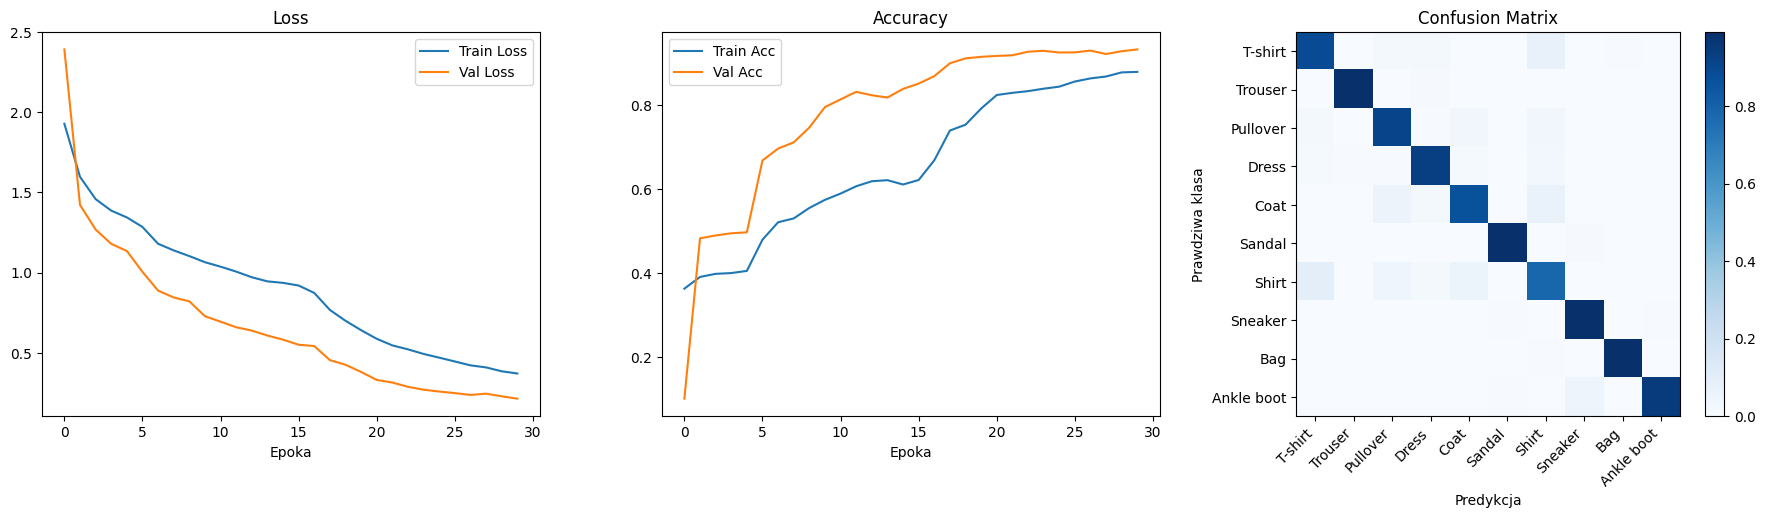

In [3]:
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

y_pred_classes = np.argmax(y_pred, axis=1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoka')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoka')
axes[1].legend()

cm = confusion_matrix(y_test, y_pred_classes)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

im = axes[2].imshow(cm_norm, cmap='Blues')
axes[2].set_xticks(range(len(class_names)))
axes[2].set_yticks(range(len(class_names)))
axes[2].set_xticklabels(class_names, rotation=45, ha='right')
axes[2].set_yticklabels(class_names)
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predykcja')
axes[2].set_ylabel('Prawdziwa klasa')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()

### Zadanie 12

In [4]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0
y_train = y_train.flatten()
y_test  = y_test.flatten()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
classes = len(class_names)

mlp = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(classes, activation='softmax')
], name='MLP')

mlp.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.25),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(classes, activation='softmax')
], name='CNN')

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6)
]

hist_mlp = mlp.fit(X_train, y_train,
                   epochs=30, batch_size=128,
                   validation_split=0.1,
                   callbacks=callbacks, verbose=1)

hist_cnn = cnn.fit(X_train, y_train,
                   epochs=30, batch_size=128,
                   validation_split=0.1,
                   callbacks=callbacks, verbose=1)

_, mlp_acc = mlp.evaluate(X_test, y_test, verbose=0)
_, cnn_acc = cnn.evaluate(X_test, y_test, verbose=0)


Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.2540 - loss: 2.0358 - val_accuracy: 0.3368 - val_loss: 1.8439 - learning_rate: 0.0010
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3125 - loss: 1.8857 - val_accuracy: 0.3628 - val_loss: 1.7814 - learning_rate: 0.0010
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3337 - loss: 1.8382 - val_accuracy: 0.3760 - val_loss: 1.7346 - learning_rate: 0.0010
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3467 - loss: 1.7975 - val_accuracy: 0.3866 - val_loss: 1.7522 - learning_rate: 0.0010
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3509 - loss: 1.7845 - val_accuracy: 0.3832 - val_loss: 1.7367 - learning_rate: 0.0010
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3630 - loss: 1.7562 - val_accuracy: 0.4032 - val_loss: 1.6842 - learning_rate: 0.0010
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3720 - loss: 1.7413 

MLP               46.73%
CNN               83.48%

CNN lepszy o: 36.75%


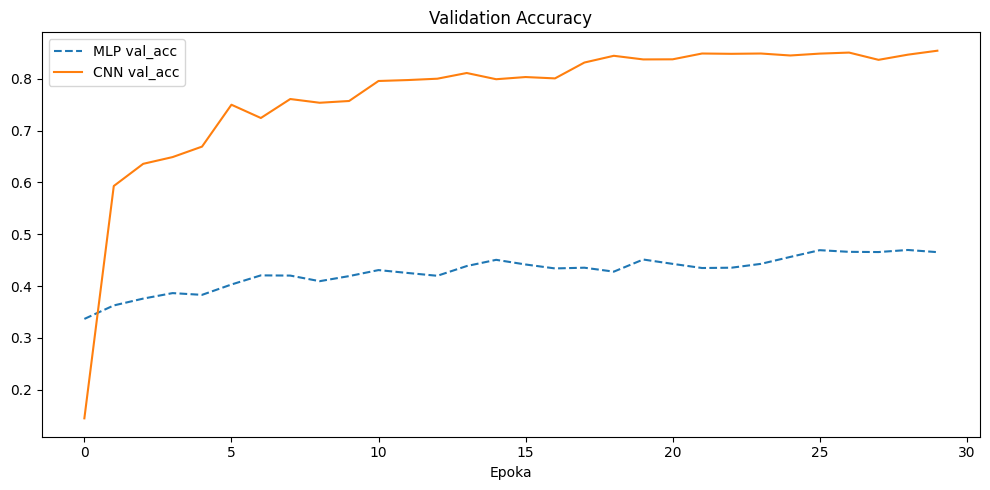

In [5]:
print(f"{'MLP':<10} {mlp_acc:>13.2%}")
print(f"{'CNN':<10} {cnn_acc:>13.2%}")
print(f"\nCNN lepszy o: {(cnn_acc - mlp_acc):.2%}")

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(hist_mlp.history['val_accuracy'], label='MLP val_acc', linestyle='--')
ax.plot(hist_cnn.history['val_accuracy'], label='CNN val_acc')
ax.set_title('Validation Accuracy')
ax.set_xlabel('Epoka')
ax.legend()

plt.tight_layout()
plt.show()